# Кластеризация данных сотрудников

Это набор данных предоставляет 10000 записей о сотрудниках.Данный набор предназначен для анализа кадровых тенденций, эффективности сотрудников, производительности и внутренних взаимодействиях в компании.


# Описание набора данных

База данных сотрудников содержит персональную информацию, контактные данные и сведения о должностях 10 000 работников.
Расшифровка каждого атрибута:
- Index - персональный индекс сотрудника
- First name - Имя сотрудника
- Last name - Фамилия сотрудника
- Sex - Пол сотрудника
- Email - Почта сотрудника
- Phone - Телефон сотрудника
- Date of birth - День рождения сотрудника
- Job Title - Должность

# Загрузка данных

## Подключение необходимых библиотек и функций

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%pip install openpyxl
%pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns


Note: you may need to restart the kernel to use updated packages.


## Обзор датасета

In [3]:
df = pd.read_csv("Employee 1000x.csv")

In [4]:
df

,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title
0,1,Sara,Mcguire,Female,tsharp@example.net,(971)643-6089x9160,17-08-21,"Editor, commissioning"
1,2,Alisha,Hebert,Male,vincentgarrett@example.net,+1-114-355-1841x78347,28-06-69,Broadcast engineer
2,3,Gwendolyn,Sheppard,Male,mercadojonathan@example.com,9017807728,25-09-15,Industrial buyer
3,4,Kristine,Mccann,Female,lindsay55@example.com,+1-607-333-9911x59088,27-07-78,Multimedia specialist
4,5,Bobby,Pittman,Female,blevinsmorgan@example.com,3739847538,17-11-89,Planning and development surveyor
...,...,...,...,...,...,...,...,...
9995,9996,Tina,Sherman,Male,bartlettcolleen@example.org,(455)476-4044x5755,28-07-74,"Scientist, physiological"
9996,9997,Earl,Jennings,Female,andreabenton@example.com,009.056.6505,20-08-32,Warehouse manager
9997,9998,Ellen,Dominguez,Female,michaelayoder@example.net,409-428-4297x469,06-06-66,Lawyer
9998,9999,Emma,Clark,Male,pstrickland@example.com,849-868-8653,09-05-07,Accounting technician


# Разведочный анализ

## Общая информация

In [5]:
df.shape

(10000, 8)

Датасет хранит в себе 10000 записей и 8 столбцов.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Index          10000 non-null  int64 
 1   First Name     10000 non-null  object
 2   Last Name      10000 non-null  object
 3   Sex            10000 non-null  object
 4   Email          10000 non-null  object
 5   Phone          10000 non-null  object
 6   Date of birth  10000 non-null  object
 7   Job Title      10000 non-null  object
dtypes: int64(1), object(7)
memory usage: 625.1+ KB


Датасет полностью заполнен, содержит 8 колонок и 10 тысяч записей. Типы данных: одна колонка числовая, а остальные — текстовые.

In [7]:
df.describe(include = "O")

,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title
count,10000,10000,10000,10000,10000,10000,10000
unique,690,1000,2,9936,9992,8646,639
top,Martin,Velazquez,Female,bnorton@example.net,-10092,19-01-11,Film/video editor
freq,28,22,5074,3,2,4,30


Этот набор не содержит пропуски. Однако в номерах телефона присутствуют аномалии.

In [8]:
print(df.duplicated().sum())

0


Дубликаты не найдены.

C:\Users\User\AppData\Local\Temp\ipykernel_1100\1000024741.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sex', palette='viridis')


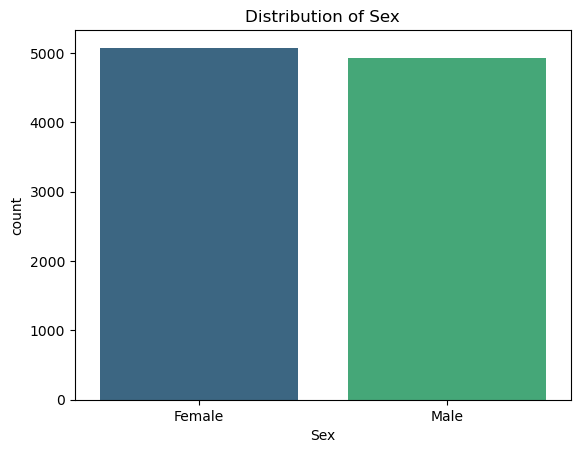

In [9]:
sns.countplot(data=df, x='Sex', palette='viridis')
plt.title('Distribution of Sex')
plt.show()

В компании женщин немного больше,чем мужчин

In [10]:
df["Job Title"].value_counts()

Job Title
Film/video editor           30
Wellsite geologist          28
Medical secretary           28
Exhibition designer         27
Probation officer           27
                            ..
Waste management officer     7
Press sub                    7
Chief Financial Officer      5
Holiday representative       5
Theatre director             5
Name: count, Length: 639, dtype: int64

более популярная должность это видеоредактор. Но нельзя сказать,что она распространена в компании т.к. записей всего 10000.

In [11]:
df["Date of birth"] = pd.to_datetime(df["Date of birth"],format = "%d-%m-%y",errors = "coerce")

In [12]:
df["Year"] = df["Date of birth"].dt.year
df.head()

,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title,Year
0,1,Sara,Mcguire,Female,tsharp@example.net,(971)643-6089x9160,2021-08-17,"Editor, commissioning",2021
1,2,Alisha,Hebert,Male,vincentgarrett@example.net,+1-114-355-1841x78347,1969-06-28,Broadcast engineer,1969
2,3,Gwendolyn,Sheppard,Male,mercadojonathan@example.com,9017807728,2015-09-25,Industrial buyer,2015
3,4,Kristine,Mccann,Female,lindsay55@example.com,+1-607-333-9911x59088,1978-07-27,Multimedia specialist,1978
4,5,Bobby,Pittman,Female,blevinsmorgan@example.com,3739847538,1989-11-17,Planning and development surveyor,1989


Исправили формат дня рождения и вывели год в отдельный столбец

In [13]:
df["Age"] = 2026 - df["Year"]

In [14]:
df["Age"]

0        5
1       57
2       11
3       48
4       37
        ..
9995    52
9996    -6
9997   -40
9998    19
9999    -9
Name: Age, Length: 10000, dtype: int32

Мы четко увидели аномалии в возрасте.Попытаемся исправить их

In [15]:
from pandas.tseries.offsets import DateOffset

In [16]:
df["Original date"] = df["Date of birth"]
df.loc[df["Age"] < 0, "Date of birth"] -= DateOffset(years = 100)
df["Update Age"] = 2025 - df["Date of birth"].dt.year

In [17]:
df.loc[df["Age"]< 0]

,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title,Year,Age,Original date,Update Age
14,15,Clayton,Erickson,Male,nterry@example.net,990-374-0521x33156,1959-02-07,Paediatric nurse,2059,-33,2059-02-07,66
19,20,Jon,Wagner,Female,meagan99@example.org,001-940-671-0693x345,1934-01-06,"Engineer, aeronautical",2034,-8,2034-01-06,91
20,21,Glen,Calderon,Male,randystephenson@example.net,4890361487,1944-09-16,"Research officer, government",2044,-18,2044-09-16,81
21,22,Marco,Sharp,Male,cmcclure@example.net,074-415-1149,1944-04-09,Retail buyer,2044,-18,2044-04-09,81
24,25,Meghan,Blanchard,Male,smejia@example.org,+1-188-201-3028x13440,1927-08-24,Occupational therapist,2027,-1,2027-08-24,98
...,...,...,...,...,...,...,...,...,...,...,...,...
9992,9993,Marvin,Davenport,Female,jade07@example.net,400-198-5125,1929-10-18,Restaurant manager,2029,-3,2029-10-18,96
9993,9994,Eddie,Clements,Female,chelsey82@example.net,855.007.8490x535,1938-06-15,Control and instrumentation engineer,2038,-12,2038-06-15,87
9996,9997,Earl,Jennings,Female,andreabenton@example.com,009.056.6505,1932-08-20,Warehouse manager,2032,-6,2032-08-20,93
9997,9998,Ellen,Dominguez,Female,michaelayoder@example.net,409-428-4297x469,1966-06-06,Lawyer,2066,-40,2066-06-06,59


In [18]:
df = df.drop(columns = ["Year", "Age", "Original date"])
df.rename(columns = {"Update Age" : "Age"}, inplace=True)

In [20]:
bins = [17,25,35,45,55,100]
labels = ["A", "B", "C", "D", "E"]
df["Age Group"] = pd.cut(df["Age"], bins = bins, labels = labels)

In [32]:
df['Sex'] = df['Sex'].replace({'Female': 1, 'Male': 0})


In [21]:
import pandas as pd
import numpy as np

df["Job Category"] = df["Job Title"]

education = df["Job Category"].str.contains(r'\b(professor|teacher|lecturer|tutor|instructor)\b', 
                                           regex=True, case=False, na=False)

administration = df["Job Category"].str.contains(r'\b(officer|secretary|administrator|clerk|assistant)\b', 
                                                regex=True, case=False, na=False)

healthcare = df["Job Category"].str.contains(
    r'\b(nurse|health|doctor|dentist|clinical|medical|therapist|psychologist|embryologist|radiographer|podiatrist|haematologist|psychotherapist|pathologist|pharmacist|veterinarian|physiotherapist|neurosurgeon|surgeon|optometrist|orthoptist|radiation|practitioner)\b',
    regex=True, case=False, na=False
)

manager = df["Job Category"].str.contains(r'\b(manager|director|supervisor|head|chief)\b', 
                                         regex=True, case=False, na=False)

tech = df["Job Category"].str.contains(r'\b(analyst|programmer|scientist|developer|specialist|technician|IT)\b', 
                                      regex=True, case=False, na=False)

engineer = df["Job Category"].str.contains(r'\b(engineer|engineering|geologist|surveyor)\b', 
                                          regex=True, case=False, na=False)

design = df["Job Category"].str.contains(r'\b(designer|editor|artist|creative|video|film|broadcast|journalist|camera|writer|copywriter|illustrator|animator|producer|lexicographer)\b', 
                                        regex=True, case=False, na=False)

consultant_sales = df["Job Category"].str.contains(r'\b(consultant|agent|representative|sales|buyer|pensions|retail|marketing|executive|account executive)\b', 
                                                  regex=True, case=False, na=False)

planning = df["Job Category"].str.contains(r'\b(planner|town planner|urban|regional|development|surveyor|event organiser|architect|landscape)\b', 
                                          regex=True, case=False, na=False)

social = df["Job Category"].str.contains(r'\b(counsellor|psychotherapist|social worker|probation|youth|community|family|careers adviser|guidance)\b', 
                                        regex=True, case=False, na=False)

science_research = df["Job Category"].str.contains(
    r'\b(scientist|researcher|analytical chemist|chemist|biologist|physicist|geoscientist|seismologist|herpetologist|ergonomist|hygienist|technologist|field|laboratory|lab)\b',
    regex=True, case=False, na=False
)

library_heritage = df["Job Category"].str.contains(
    r'\b(librarian|public librarian|archivist|curator|conservator|restorer|museum|gallery|heritage)\b',
    regex=True, case=False, na=False
)

finance_legal = df["Job Category"].str.contains(
    r'\b(tax|accountant|auditor|loss adjuster|chartered|investment|banker|corporate|legal|executive|solicitor|paralegal)\b',
    regex=True, case=False, na=False
)

agriculture_environment = df["Job Category"].str.contains(
    r'\b(horticulturist|amenity|agriculture|farmer|gardener|environmental|ecologist|conservation|forestry)\b',
    regex=True, case=False, na=False
)

emergency_security = df["Job Category"].str.contains(
    r'\b(firefighter|police|paramedic|emergency|rescue|security|safety|protection)\b',
    regex=True, case=False, na=False
)

textile_garment = df["Job Category"].str.contains(
    r'\b(garment|textile|technologist|fashion|clothing|apparel)\b',
    regex=True, case=False, na=False
)

aviation = df["Job Category"].str.contains(
    r'\b(air cabin crew|pilot|flight|aviation|airline|aircraft)\b',
    regex=True, case=False, na=False
)

other = ~(education | administration | healthcare | manager | tech | engineer | 
          design | consultant_sales | planning | social | science_research |
          library_heritage | finance_legal | agriculture_environment | 
          emergency_security | textile_garment | aviation)

conditions = [
    education, administration, healthcare, manager, tech, engineer, 
    design, consultant_sales, planning, social, science_research,
    library_heritage, finance_legal, agriculture_environment, 
    emergency_security, textile_garment, aviation, other
]

choices = [
    "education", "administration", "healthcare", "manager", "tech", "engineer",
    "design", "consultant_sales", "planning", "social", "science_research",
    "library_heritage", "finance_legal", "agriculture_environment",
    "emergency_security", "textile_garment", "aviation", "other"
]

df["Job Category"] = np.select(conditions, choices, default="other")

print(df["Job Category"].value_counts())

  

C:\Users\User\AppData\Local\Temp\ipykernel_1100\1889810039.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  education = df["Job Category"].str.contains(r'\b(professor|teacher|lecturer|tutor|instructor)\b',
C:\Users\User\AppData\Local\Temp\ipykernel_1100\1889810039.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  administration = df["Job Category"].str.contains(r'\b(officer|secretary|administrator|clerk|assistant)\b',
C:\Users\User\AppData\Local\Temp\ipykernel_1100\1889810039.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  healthcare = df["Job Category"].str.contains(
C:\Users\User\AppData\Local\Temp\ipykernel_1100\1889810039.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match gr

Job Category
healthcare                 1406
administration             1383
engineer                   1353
other                      1324
design                      958
manager                     799
tech                        714
consultant_sales            377
finance_legal               347
education                   329
science_research            306
planning                    237
library_heritage            184
social                      125
agriculture_environment      80
aviation                     46
emergency_security           32
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_1100\1889810039.py:43: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  library_heritage = df["Job Category"].str.contains(
C:\Users\User\AppData\Local\Temp\ipykernel_1100\1889810039.py:48: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  finance_legal = df["Job Category"].str.contains(
C:\Users\User\AppData\Local\Temp\ipykernel_1100\1889810039.py:53: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  agriculture_environment = df["Job Category"].str.contains(
C:\Users\User\AppData\Local\Temp\ipykernel_1100\1889810039.py:58: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  emergency_security = df["Job Categor

Вместо конкретных должностей поменяла на обобщенные категории

In [33]:
adult = df[df["Age"] >= 18]
mean_age_category = adult.groupby("Job Category")["Age"].mean()
def solve_age (row):
    if row["Age"] <= 18:
        return mean_age_category.get(row["Job Category"], np.nan)
    return row["Age"]

df["Right Age"] = df.apply(solve_age, axis = 1)

In [34]:
df["Age Group"] = pd.cut(df["Right Age"], bins = bins, labels = labels)
df.head()

,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title,Age,Age Group,Job Category,Right Age
0,1,Sara,Mcguire,1,tsharp@example.net,(971)643-6089x9160,2021-08-17,"Editor, commissioning",4,E,design,57.643875
1,2,Alisha,Hebert,0,vincentgarrett@example.net,+1-114-355-1841x78347,1969-06-28,Broadcast engineer,56,E,engineer,56.000000
2,3,Gwendolyn,Sheppard,0,mercadojonathan@example.com,9017807728,2015-09-25,Industrial buyer,10,E,consultant_sales,57.091603
3,4,Kristine,Mccann,1,lindsay55@example.com,+1-607-333-9911x59088,1978-07-27,Multimedia specialist,47,D,tech,47.000000
4,5,Bobby,Pittman,1,blevinsmorgan@example.com,3739847538,1989-11-17,Planning and development surveyor,36,C,engineer,36.000000


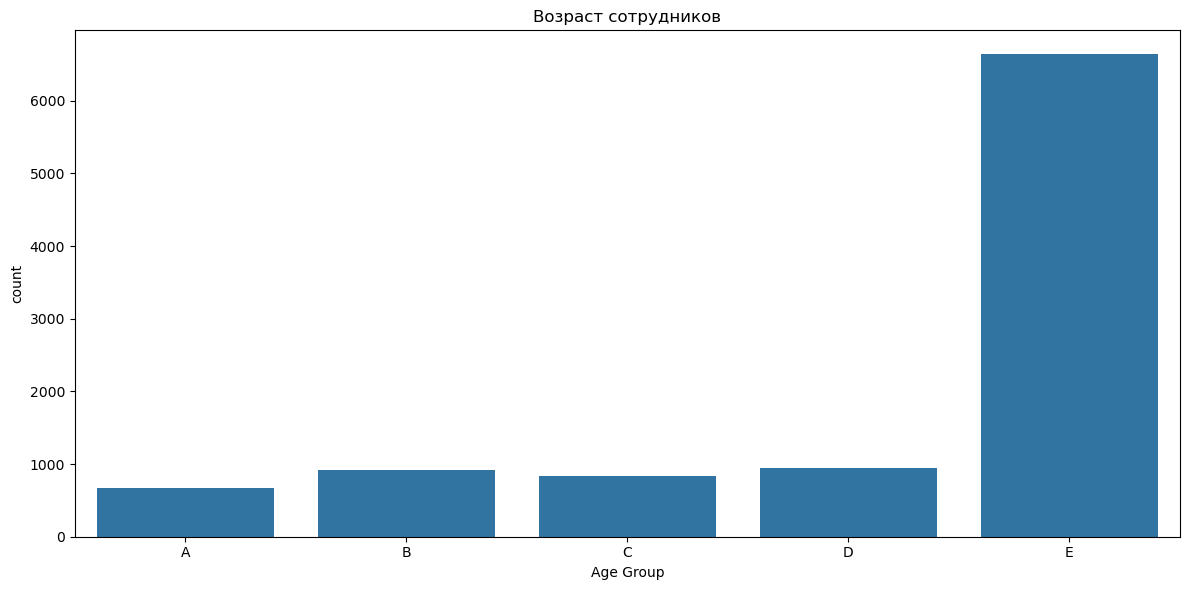

In [35]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Age Group')
plt.title('Возраст сотрудников')
plt.tight_layout()
plt.show()

In [28]:
df.to_csv("Data_for_dash_board.csv", index=False)

- Группа А(от 18 до 25 лет)
- Группа B(от 26 до 35 лет)
- Группа C(от 36 до 45 лет)
- Группа D(от 46 до 55 лет)
- Группа E(от 56 до 100 лет)
  Как мы видим группа E превосходит численностью.

C:\Users\User\AppData\Local\Temp\ipykernel_1100\2337159148.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=top_10_job_data, x="Job Title", y="Age Group", palette="viridis", ci=None)
C:\Users\User\AppData\Local\Temp\ipykernel_1100\2337159148.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_job_data, x="Job Title", y="Age Group", palette="viridis", ci=None)


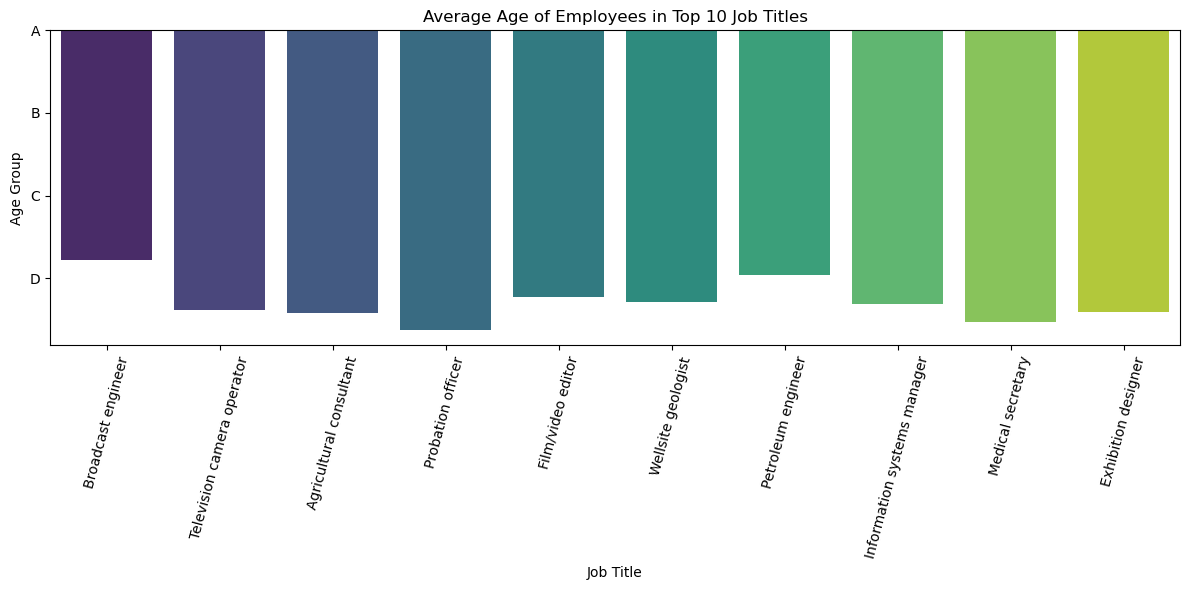

In [29]:
top_10_jobs = df["Job Title"].value_counts().head(10).index
top_10_job_data = df[df["Job Title"].isin(top_10_jobs)]

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_job_data, x="Job Title", y="Age Group", palette="viridis", ci=None)
plt.title("Распределение возраста в топ 10 профессий")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [30]:
df.head()

,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title,Age,Age Group,Job Category,Right Age
0,1,Sara,Mcguire,Female,tsharp@example.net,(971)643-6089x9160,2021-08-17,"Editor, commissioning",4,E,design,57.643875
1,2,Alisha,Hebert,Male,vincentgarrett@example.net,+1-114-355-1841x78347,1969-06-28,Broadcast engineer,56,E,engineer,56.000000
2,3,Gwendolyn,Sheppard,Male,mercadojonathan@example.com,9017807728,2015-09-25,Industrial buyer,10,E,consultant_sales,57.091603
3,4,Kristine,Mccann,Female,lindsay55@example.com,+1-607-333-9911x59088,1978-07-27,Multimedia specialist,47,D,tech,47.000000
4,5,Bobby,Pittman,Female,blevinsmorgan@example.com,3739847538,1989-11-17,Planning and development surveyor,36,C,engineer,36.000000


In [36]:
df['Right Age'] = df['Right Age'].astype(int)


приводим возраст к целому числу

# Кластеризация

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder


импорт библиотек

In [41]:
job_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
job_encoded = job_encoder.fit_transform(df[['Job Category']])


 Создаем One-Hot признаки


In [42]:
job_columns = [f"job_{cat}" for cat in job_encoder.categories_[0]]


получаем название колонок

In [43]:
features = np.hstack([
    df[['Right Age']].values,  
    df[['Sex']].values,
    job_encoded
])

features_df = pd.DataFrame(
    np.hstack([df[['Right Age', 'Sex']].values, job_encoded]),
    columns=['Right Age', 'Sex'] + job_columns
)

print(f"Всего признаков: {features.shape[1]}")

Всего признаков: 19


сбор всех признаков

In [44]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

маштабирование данных 

In [45]:
age_weight = 10  # попробуйте 3, 5, 10, 15
X_scaled_weighted = X_scaled.copy()
X_scaled_weighted[:, 0] = X_scaled[:, 0] * age_weight

X_scaled = X_scaled_weighted 

увеличиваем вес возраста так как без этого он не учитывается в кластеризации

Кластеризация K-Means,Agglomerative,DBSCAN

In [47]:
clustering_results = {}
metrics = {}
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clustering_results['K-Means'] = kmeans.fit_predict(X_scaled)

agglo = AgglomerativeClustering(n_clusters=3)
clustering_results['Agglomerative'] = agglo.fit_predict(X_scaled)

dbscan = DBSCAN(eps=0.5, min_samples=5)
clustering_results['DBSCAN'] = dbscan.fit_predict(X_scaled)

 

In [93]:
for name, labels in clustering_results.items():
    if len(set(labels)) > 1:   
        metrics[name] = {
            'Silhouette': silhouette_score(X_scaled, labels),
            'Calinski-Harabasz': calinski_harabasz_score(X_scaled, labels),
            'Davies-Bouldin': davies_bouldin_score(X_scaled, labels)
        }

metrics_df = pd.DataFrame(metrics).T
print("\nМЕТРИКИ КЛАСТЕРИЗАЦИИ:")
print(metrics_df.round(4))

 
best_method = metrics_df['Silhouette'].idxmax()
 
 


МЕТРИКИ КЛАСТЕРИЗАЦИИ:
               Silhouette  Calinski-Harabasz  Davies-Bouldin
K-Means            0.4847         15365.4285          0.7282
Agglomerative      0.4267         12678.5833          0.8177
DBSCAN             0.4894            21.6850          1.5106


Лучший метод K-Means

вывод всех метрик для кластеров

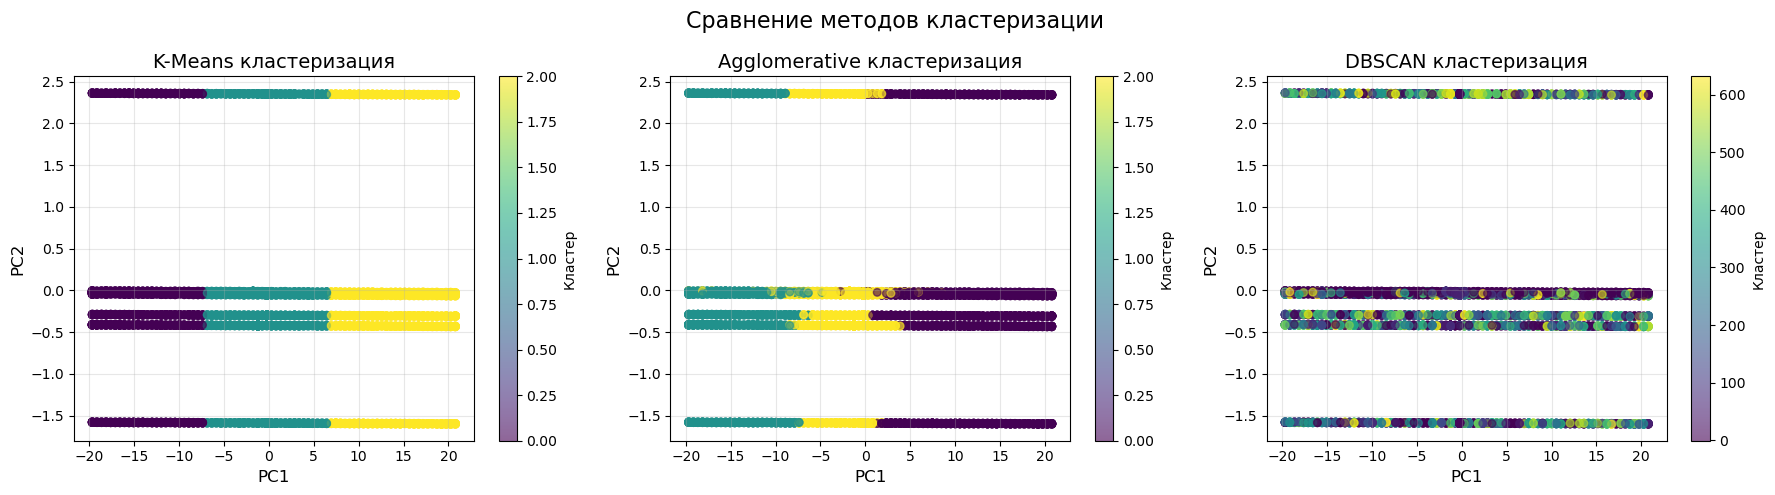

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, labels) in zip(axes, clustering_results.items()):
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.6, s=30)
    ax.set_title(f'{name} кластеризация', fontsize=14)
    ax.set_xlabel('PC1', fontsize=12)
    ax.set_ylabel('PC2', fontsize=12)
    plt.colorbar(scatter, ax=ax, label='Кластер')
    ax.grid(True, alpha=0.3)

plt.suptitle('Сравнение методов кластеризации', fontsize=16)
plt.tight_layout()
plt.show()

вывод кластеров графический видем 3 четко сформированных группы

In [54]:
df['Cluster'] = clustering_results['K-Means']
cluster_stats = df.groupby('Cluster').agg({
    'Right Age': ['mean', 'std', 'min', 'max', 'count'],
    'Sex': 'mean',
    'Job Category': lambda x: x.value_counts().index[0],  # Самая частая профессия
}).round(2)

cluster_stats.columns = ['Ср.возраст', 'Стд.возраст', 'Мин.возраст', 
                         'Макс.возраст', 'Кол-во', 'Доля женщин', 'Топ-профессия']
print(cluster_stats)


         Ср.возраст  Стд.возраст  Мин.возраст  Макс.возраст  Кол-во  \
Cluster                                                               
0             30.46         7.28           19            43    2251   
1             56.57         5.11           44            70    5328   
2             84.36         8.14           71            98    2421   

         Доля женщин Топ-профессия  
Cluster                             
0               0.50      engineer  
1               0.51    healthcare  
2               0.51    healthcare  


статистика по кластерам

In [92]:
for cluster in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster]
    
    print(f"\n КЛАСТЕР {cluster} (n={len(cluster_data)} чел., {len(cluster_data)/len(df)*100:.1f}%)")
    print(f"   Возрасттттт: {cluster_data['Right Age'].min():.0f}-{cluster_data['Right Age'].max():.0f} (ср.{cluster_data['Right Age'].mean():.1f})")
    print(f"   Пол: {cluster_data['Sex'].mean()*100:.1f}% женщин")
    print("   ТОП ПРОФЕССИЙ:")
    top5 = cluster_data['Job Category'].value_counts().head(10)
    for job, count in top5.items():
        pct = count/len(cluster_data)*100
        print(f"      {job}: {count} чел. ({pct:.1f}%)")


 КЛАСТЕР 0 (n=2251 чел., 22.5%)
   Возрасттттт: 19-43 (ср.30.5)
   Пол: 50.4% женщин
   ТОП ПРОФЕССИЙ:
      engineer: 327 чел. (14.5%)
      administration: 322 чел. (14.3%)
      healthcare: 315 чел. (14.0%)
      other: 285 чел. (12.7%)
      design: 190 чел. (8.4%)
      manager: 188 чел. (8.4%)
      tech: 164 чел. (7.3%)
      consultant_sales: 81 чел. (3.6%)
      finance_legal: 80 чел. (3.6%)
      education: 71 чел. (3.2%)

 КЛАСТЕР 1 (n=5328 чел., 53.3%)
   Возрасттттт: 44-70 (ср.56.6)
   Пол: 50.8% женщин
   ТОП ПРОФЕССИЙ:
      healthcare: 740 чел. (13.9%)
      administration: 724 чел. (13.6%)
      engineer: 712 чел. (13.4%)
      other: 708 чел. (13.3%)
      design: 529 чел. (9.9%)
      manager: 417 чел. (7.8%)
      tech: 377 чел. (7.1%)
      consultant_sales: 205 чел. (3.8%)
      finance_legal: 191 чел. (3.6%)
      education: 187 чел. (3.5%)

 КЛАСТЕР 2 (n=2421 чел., 24.2%)
   Возрасттттт: 71-98 (ср.84.4)
   Пол: 50.9% женщин
   ТОП ПРОФЕССИЙ:
      healthcare: 3

детальный анализ по профессиям

In [ ]:
Топ-профессии более менее одинаковы во всех возрастных группах!
   • healthcare стабильно в топе 
   • administration всегда 2 место 
   • engineer немного падает с возрастом 
   • design стабильно 
ВЫВОД: Люди не меняют профессию кардинально с возрастом!
однако большая часть здравоохранения находиться в более взрослых людей, а у более молодых это инжинерные специальности 

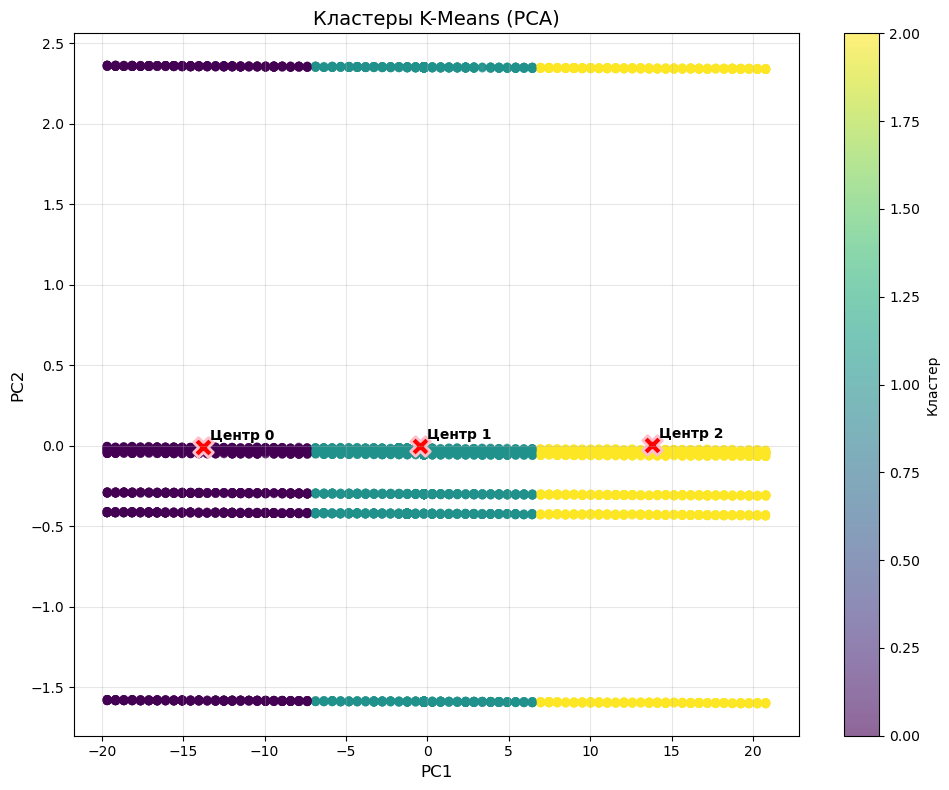

In [61]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=df['Cluster'], cmap='viridis', alpha=0.6, s=30)
plt.title('Кластеры K-Means (PCA)', fontsize=14)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.colorbar(scatter, label='Кластер')
plt.grid(True, alpha=0.3)

for cluster in sorted(df['Cluster'].unique()):
    center = X_pca[df['Cluster'] == cluster].mean(axis=0)
    plt.scatter(center[0], center[1], 
               c='red', marker='X', s=200, edgecolors='pink', linewidth=2)
    plt.annotate(f'Центр {cluster}', center, 
                fontsize=10, weight='bold',
                xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.show()
 

кластеры с центрами 

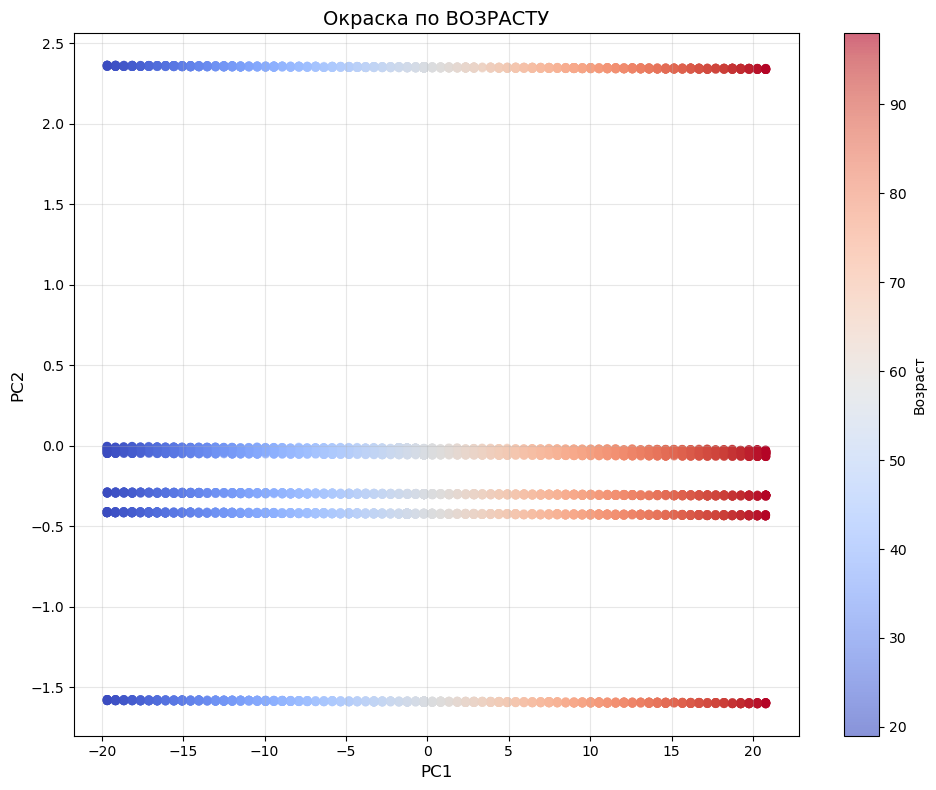

In [62]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=df['Right Age'], cmap='coolwarm', alpha=0.6, s=30)
plt.title('Окраска по ВОЗРАСТУ', fontsize=14)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.colorbar(scatter, label='Возраст')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

окраска по возрасту мы видим что возраст во всех кластерах нормально распределен 

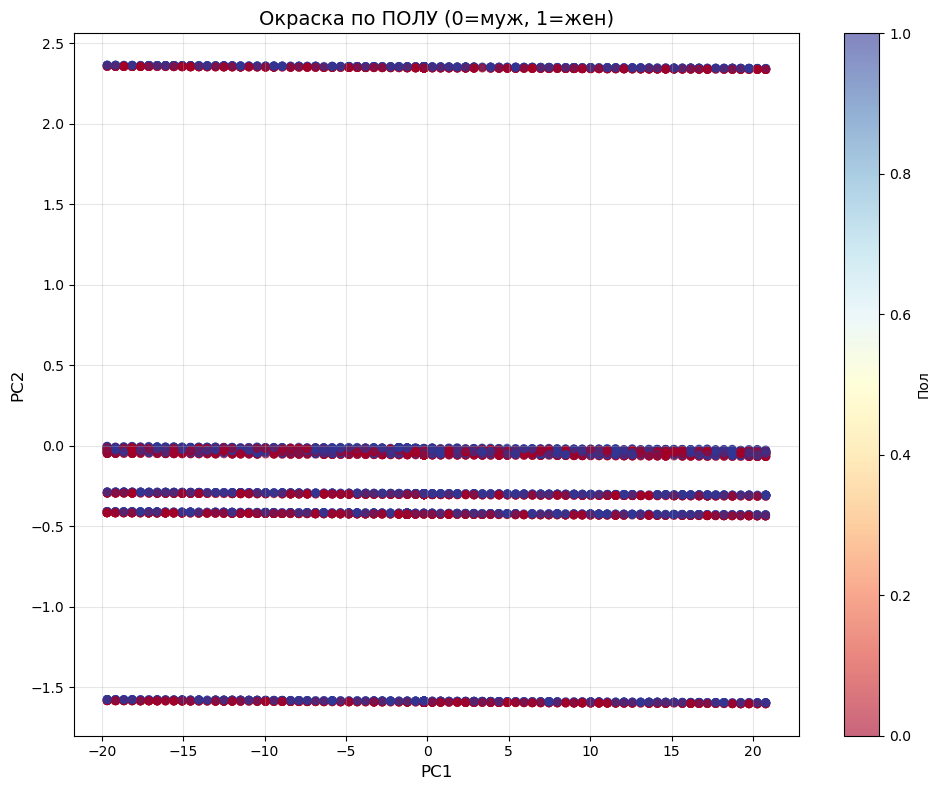

In [63]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=df['Sex'], cmap='RdYlBu', alpha=0.6, s=30)
plt.title('Окраска по ПОЛУ (0=муж, 1=жен)', fontsize=14)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.colorbar(scatter, label='Пол')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

окраска по полу

<Figure size 1000x600 with 0 Axes>

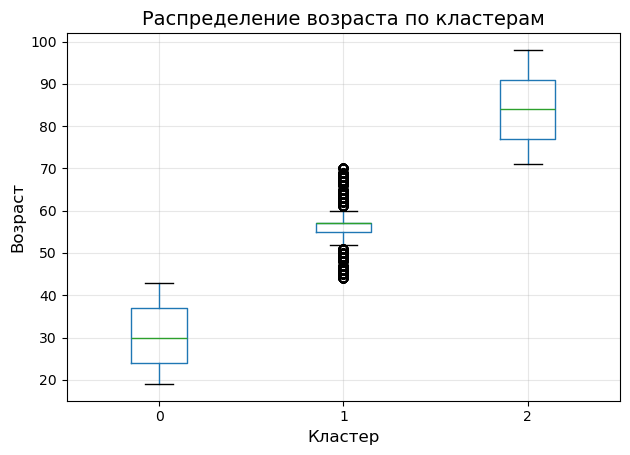

In [64]:
plt.figure(figsize=(10, 6))
df.boxplot(column='Right Age', by='Cluster')
plt.title('Распределение возраста по кластерам', fontsize=14)
plt.suptitle('')  
plt.xlabel('Кластер', fontsize=12)
plt.ylabel('Возраст', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

график распределения возраста по кластера 

<Figure size 1000x600 with 0 Axes>

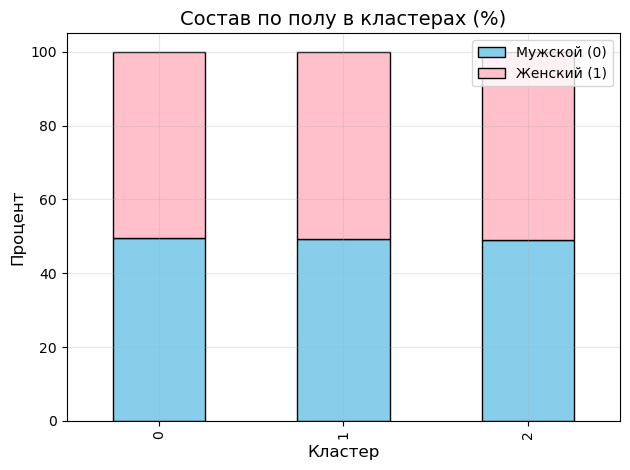

In [66]:
sex_by_cluster = pd.crosstab(df['Cluster'], df['Sex'], normalize='index') * 100
sex_by_cluster.columns = ['Мужской (0)', 'Женский (1)']

plt.figure(figsize=(10, 6))
ax = sex_by_cluster.plot(kind='bar', stacked=True, 
                        color=['skyblue', 'pink'], edgecolor='black')
plt.title('Состав по полу в кластерах (%)', fontsize=14)
plt.xlabel('Кластер', fontsize=12)
plt.ylabel('Процент', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
 

процентное соотношение полов к каждом кластере

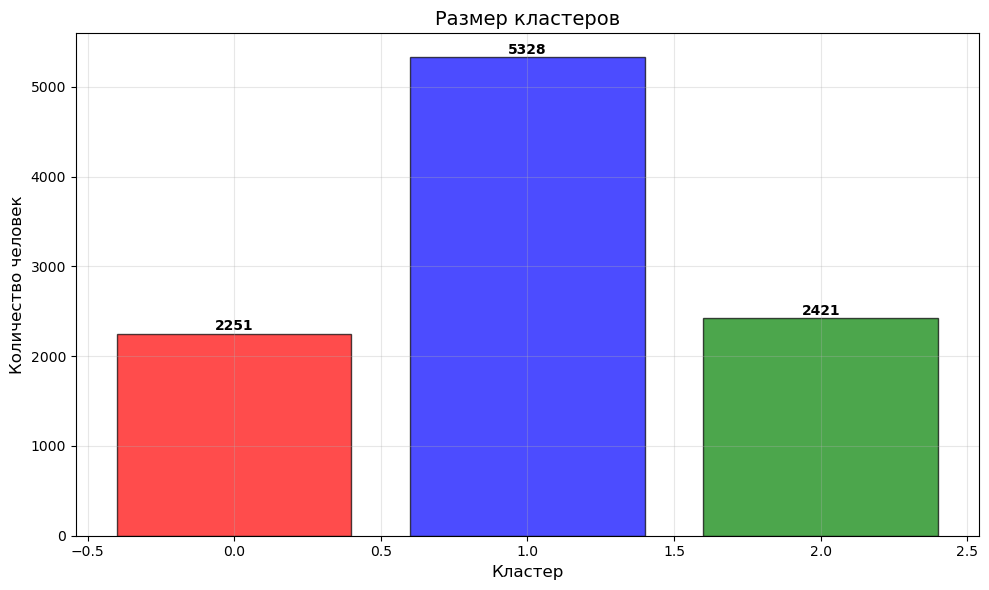

In [67]:
cluster_sizes = df['Cluster'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
bars = plt.bar(cluster_sizes.index, cluster_sizes.values, 
               color=['red', 'blue', 'green'], alpha=0.7, edgecolor='black')
plt.title('Размер кластеров', fontsize=14)
plt.xlabel('Кластер', fontsize=12)
plt.ylabel('Количество человек', fontsize=12)
plt.grid(True, alpha=0.3)

# Добавляем цифры на столбики
for bar, size in zip(bars, cluster_sizes.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{size}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

количество человек в каждом кластере

# Классификация

In [99]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [100]:
X_job = df[['Right Age', 'Sex']].copy()
y_job = df['Job Category']

выбор признаков для классификации 

In [101]:
X_train, X_test, y_train, y_test = train_test_split(
    X_job, y_job, test_size=0.25, random_state=42, stratify=y_job
)
print(f"Обучающая выборка: {len(X_train)} примеров")
print(f"Тестовая выборка: {len(X_test)} примеров")

Обучающая выборка: 7500 примеров
Тестовая выборка: 2500 примеров


разделям выбору на обучающую и тестовую 

In [102]:
scaler_job = StandardScaler()
X_train_scaled = scaler_job.fit_transform(X_train)
X_test_scaled = scaler_job.transform(X_test)

маштабирование данных

# Логистическая регрессия

In [104]:
log_reg = LogisticRegression(max_iter=1000, random_state=42, multi_class='ovr')
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)


accuracy_log = accuracy_score(y_test, y_pred_log)
print(f"Точность (Accuracy): {accuracy_log:.2%}")

y_pred_proba_log = log_reg.predict_proba(X_test_scaled)
print(f"Количество классов: {len(log_reg.classes_)}")

coef_df = pd.DataFrame(
    log_reg.coef_.T,
    index=['Возраст', 'Пол'],
    columns=log_reg.classes_
)


C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Точность (Accuracy): 12.72%
Количество классов: 17


# Рандомный лес

In [95]:
X = df[['Right Age', 'Sex']].copy()
y_category = df['Job Category']   

X_train, X_test, y_train_cat, y_test_cat = train_test_split(
    X, y_category, test_size=0.25, random_state=42, stratify=y_category
)

scaler_cat = StandardScaler()
X_train_scaled = scaler_cat.fit_transform(X_train)
X_test_scaled = scaler_cat.transform(X_test)

cat_model = RandomForestClassifier(n_estimators=100, random_state=42)
cat_model.fit(X_train_scaled, y_train_cat)
y_pred_cat = cat_model.predict(X_test_scaled)

cat_accuracy = accuracy_score(y_test_cat, y_pred_cat)
print(f"\n Точность предсказания КАТЕГОРИИ: {cat_accuracy:.2%}")

 


 Точность предсказания КАТЕГОРИИ: 19.20%


# Метод опорных веторов 

In [84]:
linear_svm = SVC(kernel='linear', random_state=42, probability=True)  # probability=True для predict_proba
linear_svm.fit(X_train_scaled, y_train)

y_pred_svm = linear_svm.predict(X_test_scaled)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Linear SVM точность: {accuracy_svm:.2%}")

Linear SVM точность: 13.28%


Вывод  
• Категория профессии почти ПОЛНОСТЬЮ определяется возрастом
• Пол не важен для определения категории
• Разные возрастные группы -> разные категории профессий

ссылка на github

https://github.com/GaliaskarovaGulshat/ML_Project.git

ссылка на дашборд 

https://datalens.yandex/rptlyesg3i3yb